# Customer Churn Prediction — Elastic Net Logistic Regression

This notebook implements the project algorithm after EDA:
**Elastic Net Regularized Logistic Regression**.

Pipeline: load data → clean `TotalCharges` → remove ID → train/test split → impute + scale + one-hot encode → tune `C` and `l1_ratio` using 5-fold cross-validation → train Elastic Net logistic regression → evaluate → compare with Logistic Regression, Decision Tree and Random Forest → inspect model coefficients → predict a new customer.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 1. Load the Telco Customer Churn dataset


In [2]:
# VS Code / local Python:
DATA_PATH = 'Telco-Customer-Churn (1).csv'

# If the CSV is in another folder, replace DATA_PATH with its full path.
df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Preprocessing

The EDA showed that `TotalCharges` needs numeric conversion. `customerID` is an identifier, not a predictive feature, so it is removed. Numerical features are imputed and standardized; categorical features are imputed and one-hot encoded.


In [3]:
df = df.copy()

# Convert blank/non-numeric TotalCharges values to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)

# Target encoding
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Remove target and customer identifier
X = df.drop(columns=['Churn', 'customerID'])

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

print('Numerical features:', numeric_features)
print('Number of categorical features:', len(categorical_features))
print('Missing TotalCharges:', df['TotalCharges'].isna().sum())
print('Churn distribution:')
print(y.value_counts())


Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Number of categorical features: 16
Missing TotalCharges: 11
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 3. Train/test split


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))


Training samples: 5634
Testing samples : 1409


## 4. Build the preprocessing pipeline

Keeping preprocessing inside a scikit-learn `Pipeline` prevents information from the test set leaking into training and cross-validation.


In [5]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])


## 5. Elastic Net Logistic Regression

Elastic Net combines L1 and L2 regularization. In scikit-learn, `l1_ratio=0` is pure L2, `l1_ratio=1` is pure L1, and values between them mix the two penalties.

We tune:
- `C`: inverse regularization strength
- `l1_ratio`: L1/L2 mixing ratio

The project uses cross-validation to choose these parameters.


In [6]:
elastic_net_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=5000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    elastic_net_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\Ishaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters: {'model__C': 10, 'model__l1_ratio': 0.5}
Best CV ROC-AUC: 0.8462


## 6. Evaluate the final Elastic Net model


In [7]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

print(pd.Series(metrics).round(4))

print('\nClassification Report')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Accuracy     0.7395
Precision    0.5060
Recall       0.7834
F1-score     0.6149
ROC-AUC      0.8406
dtype: float64

Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



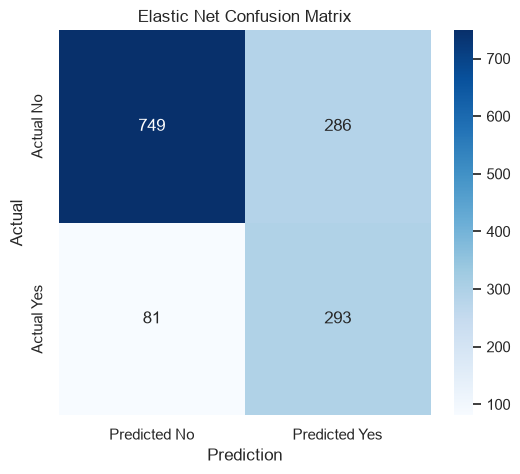

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)
plt.title('Elastic Net Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()


## 7. Benchmark against other classifiers


In [9]:
benchmark_models = {
    'Elastic Net Logistic Regression': best_model,
    'Plain Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=6,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

results = []

for name, model in benchmark_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
display(results_df)


c:\Users\Ishaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Elastic Net Logistic Regression,0.7395,0.5060,0.7834,0.6149,0.8406
Plain Logistic Regression,0.7374,0.5034,0.7834,0.6130,0.8414
Decision Tree,0.7410,0.5077,0.7914,0.6186,0.8290
Random Forest,0.7530,0.5246,0.7406,0.6142,0.8388


## 8. ROC curves


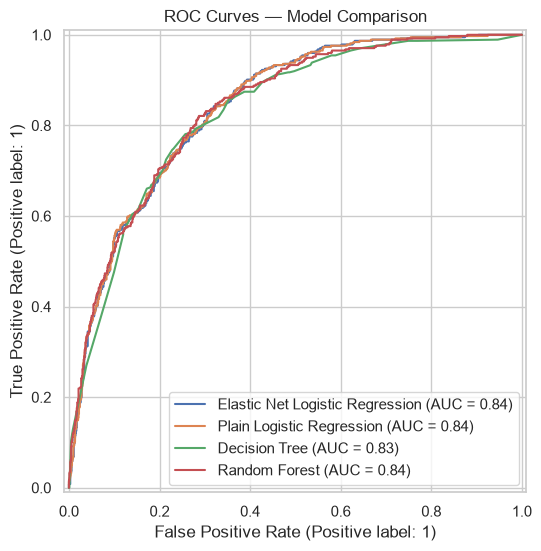

In [10]:
plt.figure(figsize=(8, 6))

for name, model in benchmark_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

plt.title('ROC Curves — Model Comparison')
plt.show()


## 9. Interpret Elastic Net coefficients

Positive coefficients increase the model's log-odds of churn; negative coefficients decrease them, holding the other transformed features constant. The coefficient magnitude indicates how strongly the feature contributes to the linear decision function.


,Feature,Coefficient,Absolute_Coefficient
1,num__MonthlyCharges,-2.051295,2.051295
17,cat__InternetService_Fiber optic,1.801623,1.801623
0,num__tenure,-1.172066,1.172066
36,cat__StreamingMovies_Yes,0.920354,0.920354
33,cat__StreamingTV_Yes,0.894030,0.894030
37,cat__Contract_Month-to-month,0.731039,0.731039
39,cat__Contract_Two year,-0.721742,0.721742
16,cat__InternetService_DSL,-0.667749,0.667749
15,cat__MultipleLines_Yes,0.574685,0.574685
2,num__TotalCharges,0.507504,0.507504


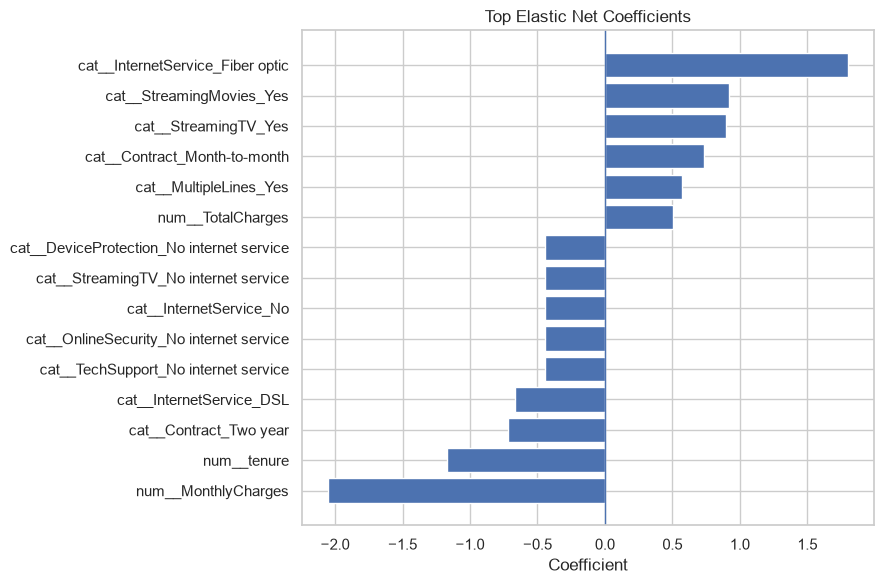

In [11]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Absolute_Coefficient', ascending=False)

display(coef_df.head(15))

plt.figure(figsize=(9, 6))
top = coef_df.head(15).sort_values('Coefficient')
plt.barh(top['Feature'], top['Coefficient'])
plt.axvline(0, linewidth=1)
plt.title('Top Elastic Net Coefficients')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()


## 10. Predict churn probability for a new customer


In [12]:
# Example customer. Replace these values with actual customer details.
new_customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 5,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0,
    'TotalCharges': 425.0
}])

probability = best_model.predict_proba(new_customer)[0, 1]
prediction = int(probability >= 0.50)

print(f'Churn probability: {probability:.2%}')
print('Prediction:', 'CHURN' if prediction == 1 else 'NO CHURN')


Churn probability: 92.51%
Prediction: CHURN


## 11. Save the trained model

The complete pipeline is saved so the same preprocessing and trained model can be reused for future predictions.


In [13]:
import joblib

joblib.dump(best_model, 'customer_churn_elastic_net.joblib')
print('Saved: customer_churn_elastic_net.joblib')


Saved: customer_churn_elastic_net.joblib


## Algorithm flow for viva

1. Load the Telco Customer Churn dataset.
2. Convert `TotalCharges` to numeric and represent invalid blanks as missing values.
3. Remove duplicate rows and the `customerID` identifier.
4. Encode `Churn`: No = 0, Yes = 1.
5. Split the data into training and testing sets using stratification.
6. Median-impute and standardize numerical variables.
7. One-hot encode categorical variables.
8. Train Elastic Net logistic regression using the SAGA solver.
9. Use 5-fold cross-validation to tune `C` and `l1_ratio` using ROC-AUC.
10. Evaluate using accuracy, precision, recall, F1-score and ROC-AUC.
11. Compare the model with plain logistic regression, decision tree and random forest.
12. Inspect coefficients to explain the important churn predictors.
13. Use the fitted pipeline to predict churn probability for a new customer.
